# Comparación jerárquica de modelos entrenados

In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from loguru import logger

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

from src.data.dataset import reconstruct_test_data
from src.evaluation import build_predictions_report
from src.evaluation.point import bias, rmse, wape
from src.evaluation.scaled import compute_naive_scales

artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))

In [2]:
comparative = []
all_model_results = []

for artifact_path in artifact_paths:

    artifact = joblib.load(artifact_path)

    grainly = "daily" if "daily" in artifact_path.name else "weekly"

    comparative.append({
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grainly,
        "winner_family": artifact["winner_family"],
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    })

    # Guarda el detalle de TODOS los modelos evaluados en este nivel
    for model_result in artifact["model_results"]:
        all_model_results.append({
            "level_label": artifact["level_label"],
            "level_id": artifact["level_id"],
            "grainly": grainly,
            **model_result,
        })

df_comparative = pd.DataFrame(comparative)
df_all_models = pd.DataFrame(all_model_results)

# Promedio de performance por modelo a nivel general (todos los niveles/grains)
df_model_avg = (
    df_all_models
    .groupby(["model","grainly"])[["wape", "wrmsse"]]
    .mean()
    .sort_values("wrmsse")
)

df_model_avg['n_levels'] = df_all_models.groupby(["model","grainly"])["level_id"].nunique()

In [3]:
df_model_avg.query('n_levels == 9 and grainly == "daily"')

,,wape,wrmsse,n_levels
model,grainly,,,
Theta,daily,0.1253,0.8974,9
ETS (Holt-Winters),daily,0.1281,0.9071,9
Seasonal naive (28d),daily,0.1427,1.0151,9
Seasonal naive (7d),daily,0.1468,1.0249,9
Seasonal naive (364d),daily,0.1374,1.0350,9
TBATS,daily,0.1706,1.1556,9
SARIMA,daily,0.1760,1.1892,9
xgboost (bench),daily,0.1677,1.1917,9
Moving average (28d),daily,0.1598,1.2031,9


In [4]:
is_tuned_variant = df_all_models["model"].str.contains(
    r"\(bench, selected features\)|\(final, Optuna\)|\(final, tuned\)", regex=True
)

df_fair = df_all_models[~is_tuned_variant].copy()
df_tuned_variants = df_all_models[is_tuned_variant].copy()

In [5]:
df_tuned_avg = (
    df_tuned_variants
    .groupby(["model","grainly"])[["wape", "wrmsse"]]
    .mean()
)

df_tuned_avg["n_levels"] = df_tuned_variants.groupby(["model","grainly"]).size()
df_tuned_avg = df_tuned_avg.sort_values("wape").reset_index()

df_tuned_avg = df_tuned_avg.query("grainly == 'daily'")

df_tuned_avg.nsmallest(10, "wape")

,model,grainly,wape,wrmsse,n_levels
1,"histgb (bench, selected features)",daily,0.0534,0.5103,1
2,"histgb (final, Optuna)",daily,0.0540,0.5118,1
8,"xgboost (final, Optuna)",daily,0.0860,0.6832,4
9,"xgboost (bench, selected features)",daily,0.1107,0.8127,8


In [6]:
df_fair_avg = (
    df_fair
    .groupby(["model","grainly"])[["wape", "wrmsse"]]
    .mean()
)

df_fair_avg["n_levels"] = df_fair.groupby(["model","grainly"]).size()
df_fair_avg = df_fair_avg.sort_values("wape").reset_index()

df_fair_avg = df_fair_avg.query("grainly == 'daily'")

df_fair_avg.nsmallest(10, "wape")

,model,grainly,wape,wrmsse,n_levels
11,Theta,daily,0.1253,0.8974,9
14,"xgboost (final, bench default)",daily,0.1267,0.8792,4
15,ETS (Holt-Winters),daily,0.1281,0.9071,9
17,Seasonal naive (364d),daily,0.1374,1.0350,9
18,Seasonal naive (28d),daily,0.1427,1.0151,9
19,Seasonal naive (7d),daily,0.1468,1.0249,9
20,Moving average (28d),daily,0.1598,1.2031,9
21,Moving average (21d),daily,0.1609,1.2175,9
22,Moving average (35d),daily,0.1621,1.2298,9
23,Moving average (14d),daily,0.1660,1.2675,9


In [7]:
ml_families = ["xgboost", "lightgbm", "histgb", "catboost", "ridge"]
bench_names = [f"{fam} (bench)" for fam in ml_families]

df_bench_ml = df_fair[df_fair["model"].isin(bench_names)].copy()
df_bench_ml["family"] = df_bench_ml["model"].str.replace(r" \(bench\)$", "", regex=True)

pivot_bench_wape = df_bench_ml.pivot_table(index="level_label", columns="family", values="wape")
pivot_bench_wape["winner_family"] = df_comparative.set_index("level_label")["winner_family"]

pivot_bench_wape.style.highlight_min(subset=ml_families, axis=1, color="#c6efce")

family,catboost,histgb,lightgbm,ridge,xgboost,winner_family
level_label,,,,,,
level_01_daily,0.159975,0.065504,0.108072,0.088916,0.066829,histgb
level_01_weekly,0.105350,0.086016,0.085232,0.064056,0.077070,xgboost
level_02_daily,0.204143,0.104641,0.109495,0.156704,0.087532,xgboost
level_02_weekly,0.130004,0.100256,0.120134,0.075908,0.105741,histgb
level_03_daily,0.401634,0.347884,0.160735,0.254016,0.132112,xgboost
level_03_weekly,0.197724,0.084065,0.098664,0.189685,0.076818,xgboost
level_04_daily,0.439099,0.393226,0.260822,0.316925,0.216202,xgboost
level_04_weekly,0.177208,0.173473,0.166333,0.171675,0.144948,histgb
level_05_daily,0.408800,0.406770,0.286350,0.418418,0.142997,xgboost


## 0. Comparativo

In [8]:
artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))

comparative = []

for artifact_path in artifact_paths:

    artifact = joblib.load(artifact_path)

    grainly = "daily" if "daily" in artifact_path.name else "weekly"

    comparative.append({
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grainly,
        "winner_family": artifact["winner_family"],
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    })

df_comparative = pd.DataFrame(comparative)

df_comparative

,level_label,level_id,grainly,winner_family,wape_test,wrmsse_test,wape_valid,wrmsse_valid
0,level_01_daily,1,daily,histgb,0.0568,0.5466,0.0540,0.5118
1,level_01_weekly,1,weekly,xgboost,0.0638,0.4512,0.0450,0.3231
2,level_02_daily,2,daily,xgboost,0.0789,0.6976,0.0655,0.5427
3,level_02_weekly,2,weekly,histgb,0.0572,0.3848,0.0448,0.3124
4,level_03_daily,3,daily,xgboost,0.0479,0.4635,0.0699,0.6422
5,level_03_weekly,3,weekly,xgboost,0.0647,0.3987,0.0451,0.3126
6,level_04_daily,4,daily,xgboost,0.0780,0.6614,0.0863,0.7299
7,level_04_weekly,4,weekly,histgb,0.0901,0.5720,0.0577,0.4014
8,level_05_daily,5,daily,xgboost,0.0735,0.6319,0.0824,0.6638
9,level_05_weekly,5,weekly,lightgbm,0.0827,0.5872,0.0657,0.4999


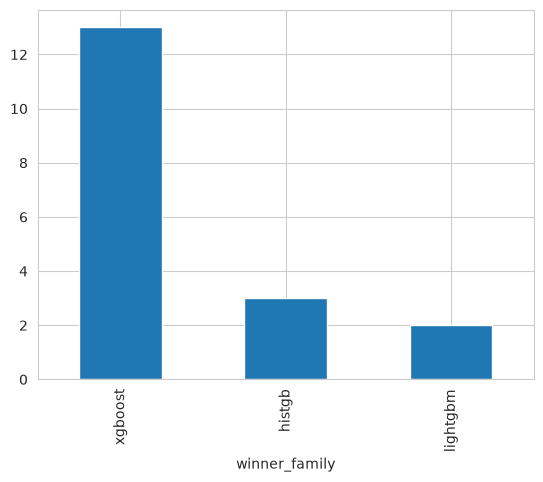

In [9]:
df_comparative.value_counts('winner_family').plot(kind='bar')
plt.show()

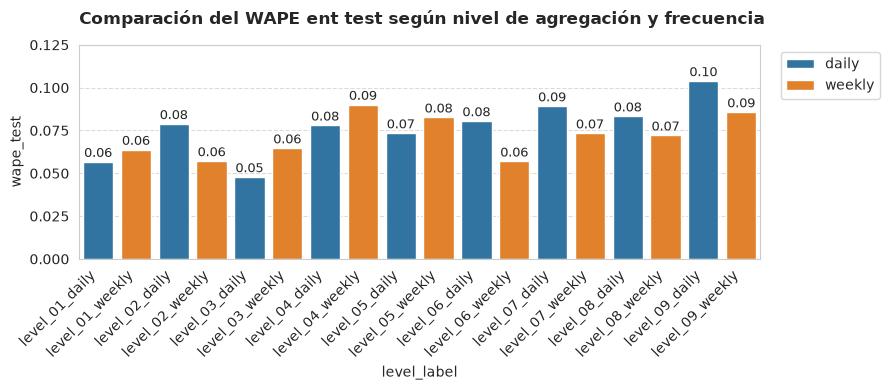

In [10]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=df_comparative,
    x="level_label",
    y="wape_test",
    hue="grainly"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 0.13, 0.025))

plt.title("Comparación del WAPE ent test según nivel de agregación y frecuencia", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

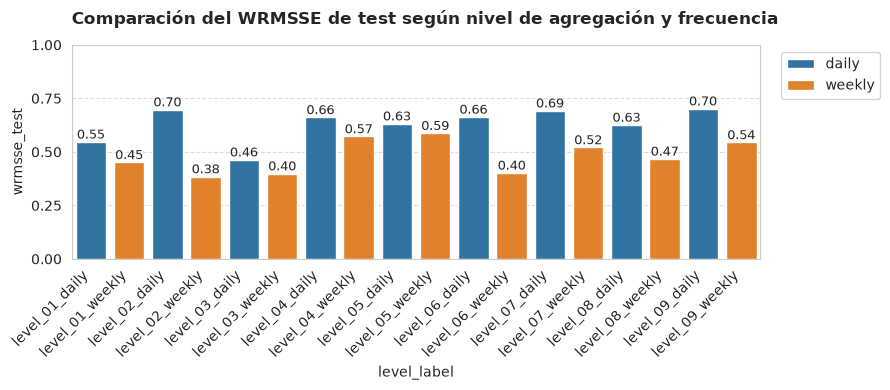

In [11]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=df_comparative,
    x="level_label",
    y="wrmsse_test",
    hue="grainly"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 1.25, 0.25))

plt.title("Comparación del WRMSSE de test según nivel de agregación y frecuencia", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [12]:
df_metrics_long = df_comparative.melt(
    id_vars=["level_label", "grainly"],
    value_vars=["wape_test", "wape_valid", "wrmsse_test", "wrmsse_valid"],
    var_name="metric_conjunto",
    value_name="valor",
)

df_metrics_long[["metric", "conjunto"]] = df_metrics_long["metric_conjunto"].str.split("_", expand=True)

df_metrics_long.drop(columns=["metric_conjunto"], inplace=True)

df_metrics_long = df_metrics_long.set_index('level_label')

df_metrics_long.head()

,grainly,valor,metric,conjunto
level_label,,,,
level_01_daily,daily,0.0568,wape,test
level_01_weekly,weekly,0.0638,wape,test
level_02_daily,daily,0.0789,wape,test
level_02_weekly,weekly,0.0572,wape,test
level_03_daily,daily,0.0479,wape,test


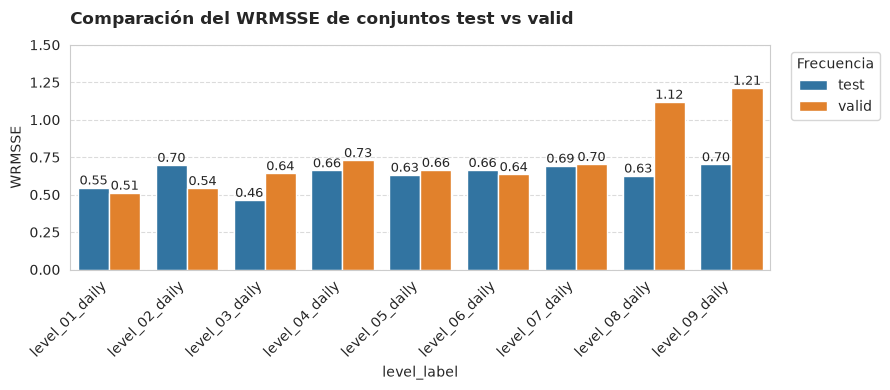

In [23]:
df_wrmsse_daily = df_metrics_long.query("metric == 'wrmsse' and grainly == 'daily'")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_wrmsse_daily,
    x="level_label",
    y="valor",
    hue="conjunto"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 1.75, 0.25))

plt.ylabel("WRMSSE")

plt.title("Comparación del WRMSSE de conjuntos test vs valid", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Frecuencia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

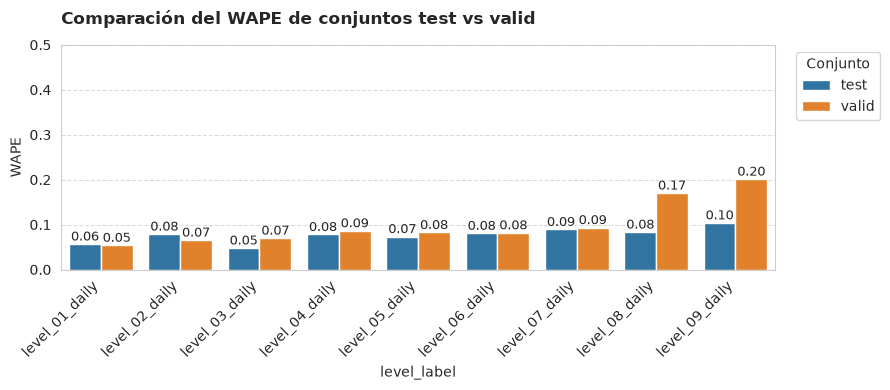

In [14]:
df_wape_daily = df_metrics_long.query("metric == 'wape' and grainly == 'daily'")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_wape_daily,
    x="level_label",
    y="valor",
    hue="conjunto"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.ylabel("WAPE")

plt.yticks(np.arange(0, .6, 0.1))

plt.title("Comparación del WAPE de conjuntos test vs valid", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Conjunto",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 1. Carga de artifacts, reconstrucción de test y predicciones

## 1.1 Carga

In [15]:
DIMS = ["dept_id", "cat_id", "store_id", "state_id"]

def load_level(artifact_path: Path) -> dict:
    '''Carga un artifact, reconstruye su X_test/train/test y arma el detalle de
    predicciones (df_pred) con las columnas de dimension (dept_id/store_id/...)
    pegadas desde X_test, para poder reagregar a cualquier nivel mas agregado.'''
    artifact = joblib.load(artifact_path)
    model = artifact["model"]

    X_test, y_test, train, test = reconstruct_test_data(artifact)
    y_pred = model.predict(X_test)

    metrics, df_pred = build_predictions_report(
        train, test, y_test, y_pred, target_col=artifact["target"],
    )
    dims_available = [d for d in DIMS if d in X_test.columns]
    df_pred = df_pred.join(X_test[dims_available])

    return {
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "level": artifact["level"],
        "model_class": type(model).__name__,
        "n_series": df_pred["series_id"].nunique(),
        "metrics": metrics,
        "df_pred": df_pred,
        "train": train,
        "dims_available": dims_available,
    }


artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
logger.info("Artifacts encontrados: {}", [p.name for p in artifact_paths])

LEVELS = {}
for path in artifact_paths:
    result = load_level(path)
    LEVELS[result["level_label"]] = result
    logger.info(
        "{} | {} series | modelo={} | WAPE test={:.2%} | WRMSSE test={:.3f}",
        result["level"], result["n_series"], result["model_class"],
        result["metrics"]["wape"], result["metrics"]["wrmsse"],
    )


2026-09-16 17:04:54.704 | INFO     | __main__:<module>:33 - Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_01_weekly_total_sales_artifact.pkl', 'level_02_daily_state_sales_artifact.pkl', 'level_02_weekly_state_sales_artifact.pkl', 'level_03_daily_cat_sales_artifact.pkl', 'level_03_weekly_cat_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_04_weekly_dept_sales_artifact.pkl', 'level_05_daily_state_cat_sales_artifact.pkl', 'level_05_weekly_state_cat_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl', 'level_06_weekly_store_sales_artifact.pkl', 'level_07_daily_state_dept_sales_artifact.pkl', 'level_07_weekly_state_dept_sales_artifact.pkl', 'level_08_daily_store_cat_sales_artifact.pkl', 'level_08_weekly_store_cat_sales_artifact.pkl', 'level_09_daily_store_dept_sales_artifact.pkl', 'level_09_weekly_store_dept_sales_artifact.pkl']
2026-09-16 17:04:54.887 | INFO     | src.data.dataset:load_data:58 - level_01_daily_total | target=sale

## 2. Resumen de cada modelo en su propio nivel nativo

In [16]:
summary_rows = []
for level_id, res in sorted(LEVELS.items()):
    m = res["metrics"]
    summary_rows.append({
        "level_label": res["level_label"],
        "level": res["level"],
        "n_series": res["n_series"],
        "modelo": res["model_class"],
        "wape": m["wape"],
        "wrmsse": m["wrmsse"],
        "bias": m["bias"],
        "rmse": m["rmse"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("level_label")
df_summary.style.format({"wape": "{:.2%}", "wrmsse": "{:.3f}", "bias": "{:.2%}", "rmse": "{:,.1f}"})


,level,n_series,modelo,wape,wrmsse,bias,rmse
level_label,,,,,,,
level_01_daily,level_01_daily_total,1,FittedModel,5.68%,0.547,-5.60%,"3,127.5"
level_01_weekly,level_01_weekly_total,1,FittedModel,6.38%,0.451,-6.38%,"21,633.4"
level_02_daily,level_02_daily_state,3,FittedModel,7.89%,0.698,-7.27%,"1,485.9"
level_02_weekly,level_02_weekly_state,3,FittedModel,5.72%,0.385,-4.07%,"6,349.3"
level_03_daily,level_03_daily_cat,3,FittedModel,4.79%,0.463,-3.95%,"1,306.0"
level_03_weekly,level_03_weekly_cat,3,FittedModel,6.47%,0.399,-5.61%,"11,064.6"
level_04_daily,level_04_daily_dept,7,FittedModel,7.80%,0.661,-5.99%,848.0
level_04_weekly,level_04_weekly_dept,7,FittedModel,9.01%,0.572,-6.33%,"5,492.5"
level_05_daily,level_05_daily_state_cat,9,FittedModel,7.35%,0.632,-2.25%,551.3


## 3. Comparación al nivel TOTAL

Se agregan (`groupby("date").sum()`) las predicciones de cada nivel a la serie
total y se comparan contra el mismo real (`sales`), que por construcción es
idéntico en todos los niveles. Esto se hace **por separado para daily y para
weekly**: cada nivel (1-8) tiene artifact nativo en ambas frecuencias, así que
no hace falta reagregar una a la otra para comparar contra L1 (que también
tiene ambos grains) -- se compara peras con peras, daily contra actual diario y
weekly contra actual semanal, sin mezclar granularidades. Es un primer paso
hacia una reconciliación jerárquica más formal (bottom-up ya está acá; top-down
por proporciones históricas o MinT/optimal reconciliation -- p.ej. con
`hierarchicalforecast` -- quedan como extensión natural).

In [17]:
def aggregate_to_total(df_pred: pd.DataFrame) -> pd.DataFrame:
    agg = df_pred.groupby("date").agg(actual=("sales", "sum"), y_pred=("y_pred", "sum"))
    return agg


def grain_of(res: dict) -> str:
    return res["level_label"].rsplit("_", 1)[-1]


# Solo se agregan al total los niveles que particionan por completo la serie total
# (item/item_store, 10-12, están filtrados a un subconjunto dept/store y no sumarían al total real).
VALID_LEVELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Cada nivel 1-8 tiene artifact nativo en daily y en weekly, así que se arma la
# comparación bottom-up/top-down por separado para cada frecuencia -- peras con
# peras -- en vez de reagregar daily a weekly para poder comparar contra L1.
levels_by_grain: dict[str, dict[int, dict]] = {"daily": {}, "weekly": {}}
for res in LEVELS.values():
    if res["level_id"] in VALID_LEVELS:
        levels_by_grain[grain_of(res)][res["level_id"]] = res

df_total_by_grain: dict[str, pd.DataFrame] = {}
for grain, levels_by_id_grain in levels_by_grain.items():
    total_aggs = {
        level_id: aggregate_to_total(res["df_pred"])
        for level_id, res in levels_by_id_grain.items()
    }
    df_total = pd.DataFrame({"actual": next(iter(total_aggs.values()))["actual"]})
    for level_id, agg in sorted(total_aggs.items()):
        df_total[f"L{level_id}"] = agg["y_pred"]
    df_total_by_grain[grain] = df_total

df_total_daily = df_total_by_grain["daily"]
df_total_weekly = df_total_by_grain["weekly"]

df_total_daily.round(0).head()

,actual,L1,L2,L3,L4,L5,L6,L7,L8,L9
date,,,,,,,,,,
2016-04-25,"38,793.0000","37,346.0000","36,167.0000","39,076.0000","38,459.0000","38,600.0000","35,837.0000","37,623.0000","37,185.0000","36,466.0000"
2016-04-26,"35,487.0000","34,937.0000","34,104.0000","34,768.0000","35,146.0000","37,170.0000","33,779.0000","34,851.0000","33,890.0000","34,508.0000"
2016-04-27,"34,445.0000","34,236.0000","32,996.0000","32,935.0000","33,398.0000","36,623.0000","32,615.0000","34,041.0000","33,303.0000","33,205.0000"
2016-04-28,"34,732.0000","33,871.0000","34,552.0000","33,958.0000","34,304.0000","36,821.0000","33,587.0000","33,928.0000","32,938.0000","34,174.0000"
2016-04-29,"42,896.0000","41,788.0000","41,253.0000","42,565.0000","41,570.0000","41,478.0000","44,394.0000","40,111.0000","39,625.0000","41,616.0000"


In [18]:
def compute_total_metrics(df_total: pd.DataFrame, train_total_df: pd.DataFrame) -> pd.DataFrame:
    """Métricas del total (WAPE/BIAS/RMSE/WRMSSE) para cada columna de predicción
    de df_total contra `actual`. La escala WRMSSE es el MSE del naive de 1 paso
    in-sample sobre el train nativo de esa frecuencia (la serie total es una sola
    serie -- no hay ponderación entre grupos)."""
    train_total = train_total_df[["date", "sales"]].copy()
    train_total["series_id"] = "TOTAL"
    scale_total = compute_naive_scales(train_total, group_col="series_id", target_col="sales")["TOTAL"]

    rows = []
    for col in [c for c in df_total.columns if c != "actual"]:
        y_true, y_pred = df_total["actual"], df_total[col]
        rows.append({
            "enfoque": col,
            "wape": wape(y_true, y_pred),
            "bias": bias(y_true, y_pred),
            "rmse": rmse(y_true, y_pred),
            "wrmsse": rmse(y_true, y_pred) / np.sqrt(scale_total),
        })
    return pd.DataFrame(rows).sort_values("wape").reset_index(drop=True)


df_total_metrics_daily = compute_total_metrics(df_total_daily, levels_by_grain["daily"][1]["train"])
df_total_metrics_weekly = compute_total_metrics(df_total_weekly, levels_by_grain["weekly"][1]["train"])

df_total_metrics_daily["grainly"] = "daily"
df_total_metrics_weekly["grainly"] = "weekly"

df_total_metrics = pd.concat([df_total_metrics_daily, df_total_metrics_weekly], ignore_index=True)
df_total_metrics

,enfoque,wape,bias,rmse,wrmsse,grainly
0,L3,0.0407,-0.0395,"2,521.0982",0.4406,daily
1,L5,0.0495,-0.0225,"2,799.9506",0.4894,daily
2,L9,0.0523,-0.0493,"2,750.2394",0.4807,daily
3,L8,0.0555,-0.0549,"3,017.8790",0.5275,daily
4,L1,0.0568,-0.0560,"3,127.5285",0.5466,daily
5,L4,0.0642,-0.0599,"3,519.2931",0.6151,daily
6,L7,0.0659,-0.0639,"3,377.4015",0.5903,daily
7,L6,0.0663,-0.0535,"3,514.1482",0.6142,daily
8,L2,0.0736,-0.0727,"3,880.0890",0.6782,daily
9,L2,0.0407,-0.0407,"14,348.2776",0.2993,weekly


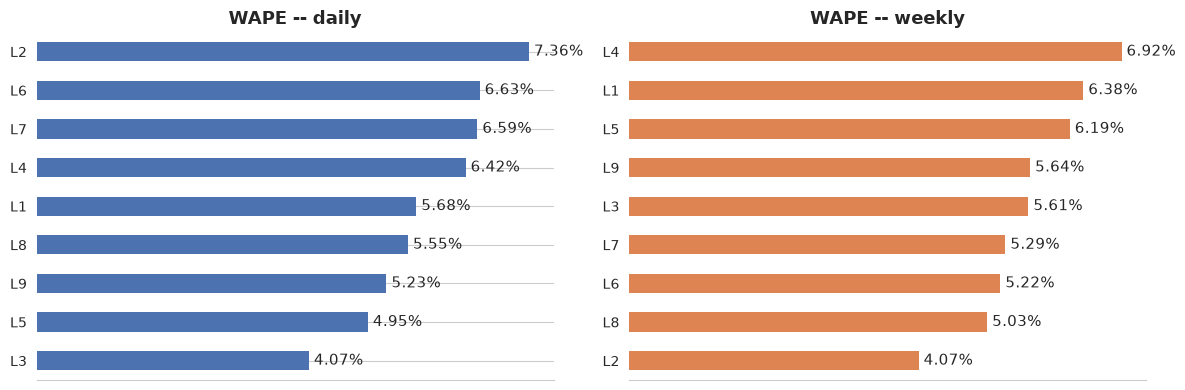

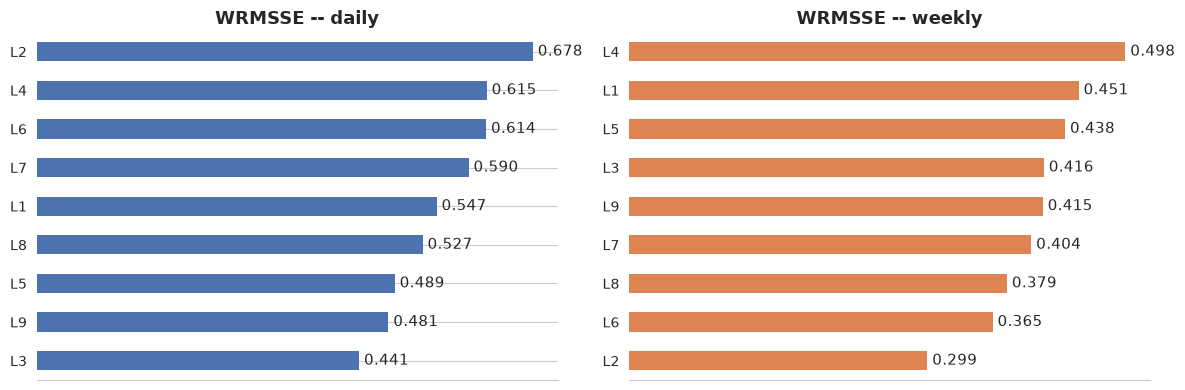

In [19]:
import matplotlib.pyplot as plt

metrics = {"wape": ("WAPE", "%"), "wrmsse": ("WRMSSE", "num")}
colors = {"daily": "#4C72B0", "weekly": "#DD8452"}

for metric, (title, fmt_type) in metrics.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, grain in zip(axes, ["daily", "weekly"]):
        data = (
            df_total_metrics.query("grainly == @grain")
            .set_index("enfoque")[metric]
            .sort_values()
        )
        data.plot(kind="barh", ax=ax, color=colors[grain], edgecolor="none")

        ax.set_title(f"{title} -- {grain}", fontsize=13, fontweight="bold")
        ax.set_ylabel("")
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.tick_params(left=False)
        ax.set_xticks([])

        for i, v in enumerate(data):
            label = f"{v:.2%}" if fmt_type == "%" else f"{v:.3f}"
            ax.text(v, i, f" {label}", va="center", fontsize=11)

    plt.tight_layout()
    plt.grid(False)
    plt.show()

In [20]:
STYLES = [
    {"color": "#E4572E", "linestyle": "--", "marker": "s"},
    {"color": "#4C72B0", "linestyle": "-.", "marker": "^"},
    {"color": "#55A868", "linestyle": ":", "marker": "D"},
    {"color": "#8172B2", "linestyle": "-", "marker": "v"},
    {"color": "#CCB974", "linestyle": "--", "marker": "o"},
    {"color": "#64B5CD", "linestyle": "-.", "marker": "P"},
    {"color": "#937860", "linestyle": ":", "marker": "X"},
]


def plot_total_vs_actual(df_total: pd.DataFrame, grain: str, cols: list[str] | None = None):
    cols = cols or [c for c in df_total.columns if c != "actual"]
    df_plot = df_total[["actual", *cols]].copy()

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(df_plot.index, df_plot["actual"], label="Real", color="black",
            linewidth=2.5, marker="o", markersize=4, zorder=3)

    for col, style in zip(cols, STYLES):
        ax.plot(df_plot.index, df_plot[col], label=col, alpha=0.8,
                linewidth=1.8, markersize=4, zorder=2, **style)

    ax.set_title(f"Total de ventas ({grain}): real vs. directo (L1) vs. bottom-up", loc="left")
    ax.set_xlabel("")
    if grain == "weekly":
        ax.set_xticks(df_plot.index)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9, frameon=False)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.ylim(0)
    plt.show()

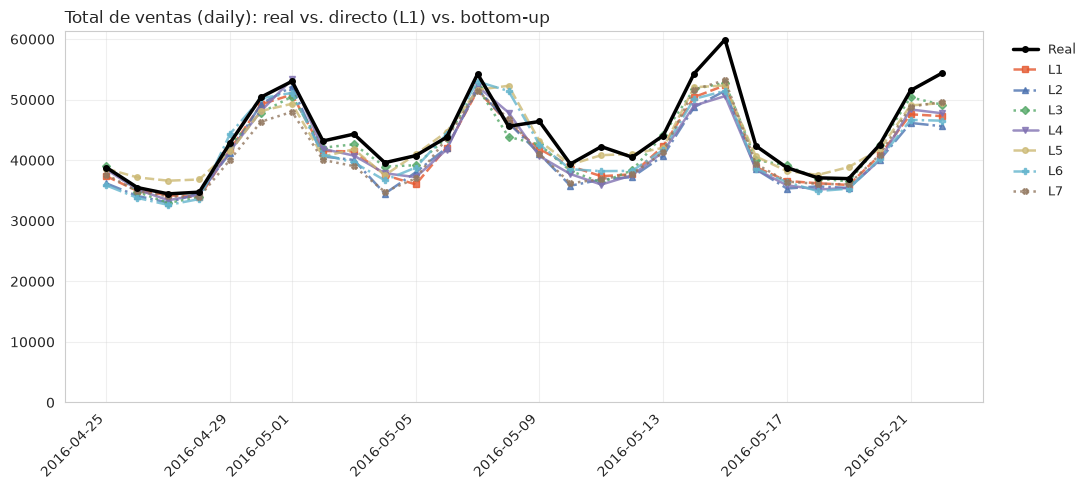

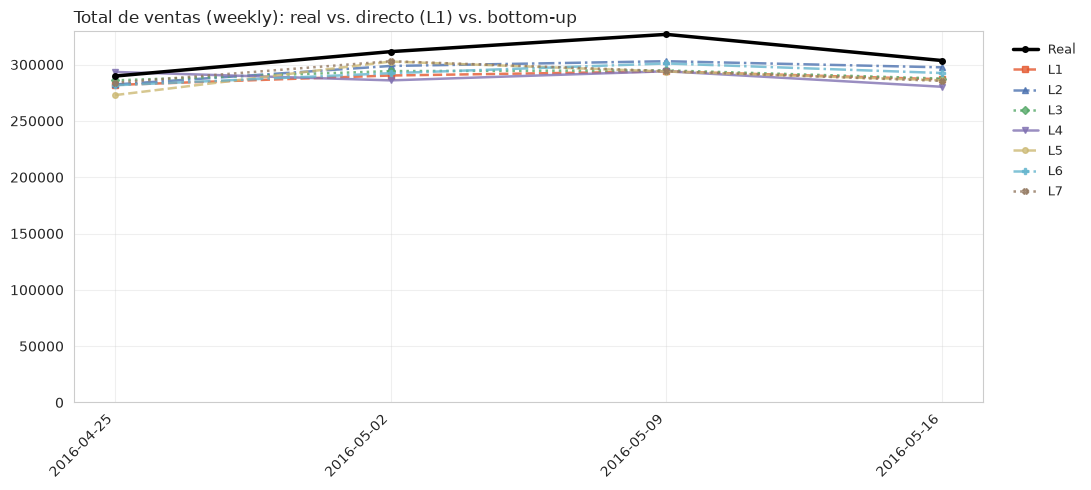

In [21]:
plot_total_vs_actual(df_total_daily, "daily", cols=['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9'])
plot_total_vs_actual(df_total_weekly, "weekly", cols=["L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8", "L9"])